In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_venn
# import Bio
# import Levenshtein
from tqdm import tqdm

In [5]:
'''
Load the gene sequences
'''

test_genes = set([])
test_lens = []
with open("gene_sequences/test_genes.fna","r") as f:
    for line in f:
        if (">" in line) or (line == "\n"):
            pass
        else:
            test_genes.add(line.strip())
            test_lens.append(len(line.strip()))


train_genes = set([])
train_lens = []
with open("gene_sequences/training_genes.fna","r") as f:
    for line in f:
        if (">" in line) or (line == "\n"):
            pass
        else:
            train_genes.add(line.strip())
            train_lens.append(len(line.strip()))

# with open("gene_sequences/test_unique_gene_seqs.txt","r") as f:
#     test_genes = set(f.readlines())

# with open("gene_sequences/train_unique_gene_seqs.txt","r") as f:
#     train_genes = set(f.readlines())



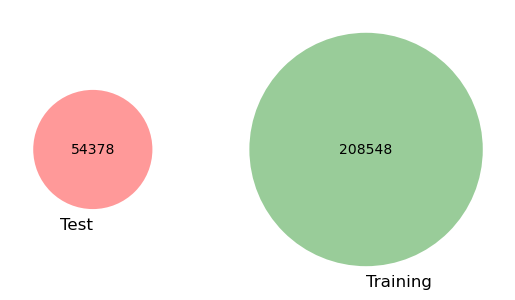

In [6]:
'''
Plot histograms of identical sequence overlap
'''

matplotlib_venn.venn2((test_genes, train_genes), set_labels=("Test","Training"))

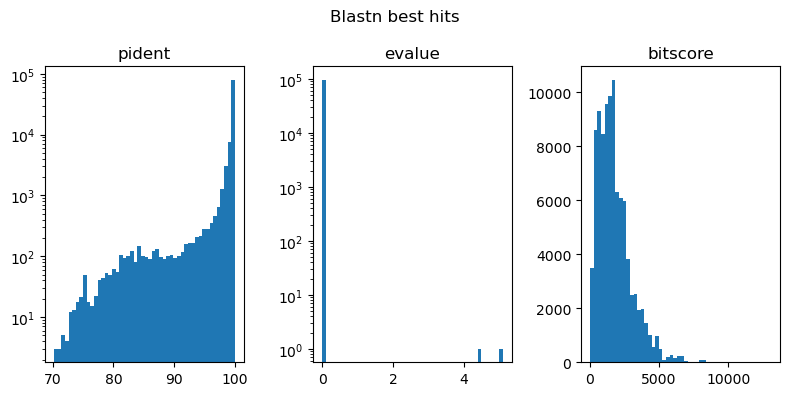

In [7]:
'''
Plot histograms of homology
'''

blast_cols = ["qseqid","sseqid","pident","length","mismatch","gapopen",
              "qstart","qend","sstart","send","evalue","bitscore"]
blast_df = pd.read_csv("blast/test_against_train.out", sep="\t", names=blast_cols,
                       index_col="qseqid")

# blast_df = blast_df.loc[blast_df["evalue"] < 0.05]

logbool = [True, True, False]

fig,ax = plt.subplots(1,len(logbool), figsize=(8,4))
for ix,col in enumerate(["pident", "evalue","bitscore"]):
    _ = ax[ix].hist(blast_df[col], bins=50, log=logbool[ix])
    ax[ix].set_title(col)

fig.suptitle("Blastn best hits")
plt.tight_layout()

In [8]:
# '''
# Collect test genes with no hits in the training set
# '''

# ## Find the sequence indices that have no blast hits in the training set
# n_test_genes = 98754+1
# no_hits = []
# _s = set(blast_df.index)
# for ix in range(n_test_genes):
#     if ix not in _s:
#         no_hits.append(ix)

# no_hits = set(no_hits)

# ## Create a fasta file containing the sequences of the genes with no hits
# nohit_fasta = ""
# with open("gene_sequences/test_genes.fasta","r") as f:

#     for l in tqdm(f.readlines()):
#         if l[0] == ">":
#             idx = l[1:].rstrip("\n")
#         # if l[0] not in {"\n",">"} and idx in no_hits:
#         if int(idx) in no_hits:
#             nohit_fasta += l
#         pass

# ## Write the new fasta
# with open("gene_sequences/test_genes_no_hit.fasta","w") as f:
#     f.write(nohit_fasta)


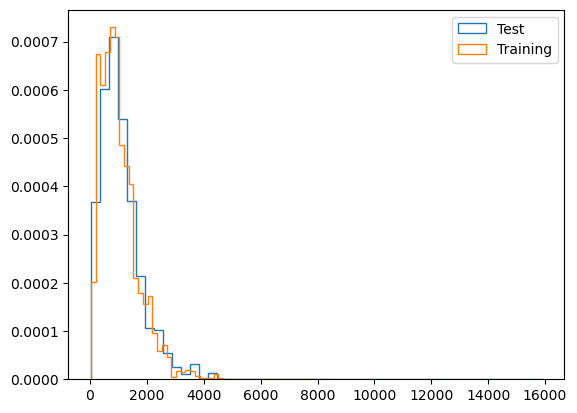

In [15]:
'''
Plot histograms of gene length in each set
'''
_ = plt.hist(test_lens, bins=50, density=True, histtype="step", label="Test")
_ = plt.hist(train_lens, bins=50, density=True, histtype="step", label="Training")
plt.legend()

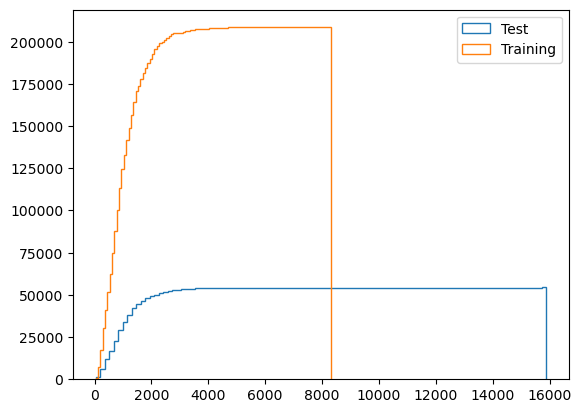

In [18]:
_ = plt.hist(test_lens, bins=100, density=False, cumulative=True, histtype="step", label="Test")
_ = plt.hist(train_lens, bins=100, density=False, cumulative=True, histtype="step", label="Training")
plt.legend()